# Threshold Stability Analysis in Deepfake Audio Detection

**Hypothesis:** CNN-based deepfake audio detectors exhibit *stable AUC* but *unstable decision thresholds* across cross-validation folds — a measurable and under-reported deployment risk.

**Dataset:** IndieFake · Log-Mel spectrograms 128×94 · 18,105 samples (7,172 real / 10,933 fake)

> Set `LOAD_CACHE = True` after the first run to skip re-training (~25–40 min on CPU).

In [1]:
import os, pickle, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
from torch.cuda.amp import autocast, GradScaler

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.interpolate import interp1d
from scipy.special import expit as sigmoid_fn
from scipy.stats import norm, wilcoxon
import pandas as pd

import sklearn
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, auc, brier_score_loss, confusion_matrix
)

# ── Reproducibility ──────────────────────────────────────────────
RANDOM_STATE = 11
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Hyperparameters ──────────────────────────────────────────────
OUTER_SPLITS = 5       # outer folds  → isolated test set each
INNER_SPLITS = 2       # inner folds  → threshold tuning
EPOCHS       = 6       # OneCycleLR converges fast; 6 is sufficient
PATIENCE     = 3       # early-stopping patience
BATCH_SIZE   = 64
LR           = 5e-4
NOISE_LEVELS = [0.0, 0.01, 0.05, 0.10]
PLOT_DIR     = "."
CACHE_FILE   = "fold_records_cache.pkl"
LOAD_CACHE   = False   # ← set True after first run

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = device.type == 'cuda'
N_WORKERS = 2 if device.type == 'cuda' else 0

# ── Publication-quality plot style ───────────────────────────────
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 10,
    'axes.labelsize'   : 11,
    'axes.titlesize'   : 11,
    'axes.titleweight' : 'bold',
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
    'legend.fontsize'  : 8.5,
    'legend.framealpha': 0.85,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
    'axes.linewidth'   : 0.8,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'grid.linewidth'   : 0.5,
    'grid.alpha'       : 0.35,
})
PAL = plt.cm.tab10.colors   # consistent 10-color palette

print(f"Device: {device}  |  AMP: {USE_AMP}  |  torch {torch.__version__}")
print(f"Outer={OUTER_SPLITS}  Inner={INNER_SPLITS}  → {OUTER_SPLITS*INNER_SPLITS} training runs")
print(f"Cache mode: {'LOAD' if LOAD_CACHE else 'RETRAIN'}")


Device: cpu  |  AMP: False  |  torch 2.10.0+cpu
Outer=5  Inner=2  → 10 training runs
Cache mode: RETRAIN


## Cell 2 — Load & Validate Dataset

In [3]:
X = np.load('X_features.npy')   # (18105, 128, 94, 1)
y = np.load('y_labels.npy')     # (18105,)  0=real  1=fake

n_real = (y == 0).sum()
n_fake = (y == 1).sum()
POS_WEIGHT = torch.tensor([n_real / n_fake]).to(device)   # for BCEWithLogitsLoss

print(f"X: {X.shape}  |  y: {y.shape}")
print(f"Real: {n_real}  Fake: {n_fake}  ratio: {n_fake/n_real:.3f}")
print(f"Feature range: [{X.min():.3f}, {X.max():.3f}]  μ={X.mean():.3f}  σ={X.std():.3f}")
print(f"pos_weight: {POS_WEIGHT.item():.4f}  (upweights real class in loss)")


X: (18105, 128, 94, 1)  |  y: (18105,)
Real: 7172  Fake: 10933  ratio: 1.524
Feature range: [-80.000, 0.000]  μ=-52.010  σ=18.373
pos_weight: 0.6560  (upweights real class in loss)


## Cell 3 — Dataset, CNN Model & LR Baseline

In [4]:
class AudioDataset(Dataset):
    """(N,H,W,C) → (N,C,H,W) tensors with contiguous memory for fast DataLoader."""
    def __init__(self, features, labels):
        self.X = torch.from_numpy(features).permute(0,3,1,2).float().contiguous()
        self.y = torch.from_numpy(labels).float().unsqueeze(1).contiguous()
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


class DeepfakeDetector(nn.Module):
    """Fixed 2-block CNN. Architecture is intentionally simple:
    the contribution is the evaluation methodology, not the model."""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool  = nn.MaxPool2d(2, 2)
        self.ap    = nn.AdaptiveAvgPool2d((8, 8))
        self.fc    = nn.Sequential(
            nn.Linear(64*8*8, 128), nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        return self.fc(torch.flatten(self.ap(x), 1))


def train_lr_baseline(train_idx, val_idx):
    """LR baseline on mean-pooled features. Used in Exp 1 ablation:
    similar threshold std to CNN proves instability is framework-level."""
    X_2d = np.column_stack([
        X.mean(axis=(1,3)).reshape(len(X),-1),   # mean over time axis
        X.mean(axis=(2,3)).reshape(len(X),-1),   # mean over freq axis
    ])
    clf = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000,
                              class_weight='balanced', random_state=RANDOM_STATE)
    clf.fit(X_2d[train_idx], y[train_idx])
    return clf.predict_proba(X_2d[val_idx])[:,1], y[val_idx]


total_params = sum(p.numel() for p in DeepfakeDetector().parameters())
print(f"CNN parameters: {total_params:,}")


CNN parameters: 543,553


## Cell 4 — Metric & Calibration Helpers

In [5]:
def make_loader(dataset, indices):
    return DataLoader(dataset, batch_size=BATCH_SIZE,
                      sampler=SubsetRandomSampler(indices),
                      num_workers=N_WORKERS, pin_memory=(device.type=='cuda'))


def get_logits_probs(model, loader):
    """Returns (logits, probs, labels) — numpy arrays."""
    model.eval()
    logits_l, probs_l, labels_l = [], [], []
    with torch.no_grad():
        for bx, by in loader:
            raw = model(bx.to(device)).cpu().numpy().ravel()
            logits_l.extend(raw)
            probs_l.extend(sigmoid_fn(raw))
            labels_l.extend(by.numpy().ravel())
    return np.array(logits_l), np.array(probs_l), np.array(labels_l)


def youden_threshold(probs, labels):
    """Threshold maximising Youden J = TPR - FPR."""
    fpr, tpr, thresholds = roc_curve(labels, probs)
    j = tpr - fpr
    idx = np.argmax(j)
    return float(thresholds[idx]), float(j[idx]), fpr, tpr


def eer_threshold(probs, labels):
    """EER via linear interpolation — more accurate than nearest-point lookup."""
    fpr, tpr, thresholds = roc_curve(labels, probs)
    fnr  = 1.0 - tpr
    diff = fpr - fnr
    sc   = np.where(np.diff(np.sign(diff)))[0]
    if len(sc) == 0:
        idx = np.nanargmin(np.abs(diff))
        return float(thresholds[idx]), float((fpr[idx]+fnr[idx])/2), fpr, tpr, fnr
    idx = sc[0]
    t   = diff[idx] / (diff[idx] - diff[idx+1] + 1e-12)
    return (float(thresholds[idx] + t*(thresholds[idx+1]-thresholds[idx])),
            float(fpr[idx] + t*(fpr[idx+1]-fpr[idx])),
            fpr, tpr, fnr)


def full_metrics(probs, labels, threshold, label=''):
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
    far = fp / (fp + tn + 1e-8)
    frr = fn / (fn + tp + 1e-8)
    return dict(
        label=label, threshold=threshold,
        accuracy=accuracy_score(labels, preds),
        f1=f1_score(labels, preds, zero_division=0),
        auc=roc_auc_score(labels, probs),
        sensitivity=tp/(tp+fn+1e-8),
        specificity=tn/(tn+fp+1e-8),
        precision=tp/(tp+fp+1e-8),
        far=far, frr=frr,
        brier=brier_score_loss(labels, probs),
        tp=int(tp), tn=int(tn), fp=int(fp), fn=int(fn),
    )


def platt_calibrate(cal_logits, cal_labels, test_logits):
    lr = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000)
    lr.fit(cal_logits.reshape(-1,1), cal_labels)
    return lr.predict_proba(test_logits.reshape(-1,1))[:,1]


def find_temperature(cal_logits, cal_labels):
    """Grid-search T in [0.1, 5] minimising Brier score."""
    best_t, best_b = 1.0, float('inf')
    for t in np.linspace(0.1, 5.0, 100):
        b = brier_score_loss(cal_labels, sigmoid_fn(cal_logits / t))
        if b < best_b:
            best_b, best_t = b, t
    return best_t


def ece_score(probs, labels, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    ece  = 0.0
    for i in range(n_bins):
        mask = (probs >= bins[i]) & (probs < bins[i+1])
        if mask.sum() == 0: continue
        ece += mask.sum() * abs(labels[mask].mean() - probs[mask].mean())
    return float(ece / len(probs))


print("All helpers defined.")


All helpers defined.


## Cell 5 — Training Utility

Key choices: `AdamW` + `OneCycleLR` for fast convergence, `pos_weight` for imbalance, AMP for GPU throughput. Returns raw logits for calibration fitting.

In [6]:
def train_fold(train_idx, val_idx, dataset, pos_weight):
    train_loader = make_loader(dataset, train_idx)
    val_loader   = make_loader(dataset, val_idx)

    model     = DeepfakeDetector().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=LR,
        steps_per_epoch=len(train_loader), epochs=EPOCHS)
    scaler = GradScaler(enabled=USE_AMP)

    best_auc, best_state, patience_ctr = -1, None, 0
    history = {'train_loss':[], 'val_loss':[], 'val_auc':[]}

    for epoch in range(1, EPOCHS+1):
        model.train()
        t_loss = 0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            with autocast(enabled=USE_AMP):
                loss = criterion(model(bx), by)
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update(); scheduler.step()
            t_loss += loss.item()
        history['train_loss'].append(t_loss / len(train_loader))

        model.eval()
        v_loss = 0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                with autocast(enabled=USE_AMP):
                    v_loss += criterion(model(bx), by).item()
        history['val_loss'].append(v_loss / len(val_loader))

        _, vp, vl = get_logits_probs(model, val_loader)
        v_auc = roc_auc_score(vl, vp)
        history['val_auc'].append(v_auc)

        if v_auc > best_auc:
            best_auc = v_auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                break

    model.load_state_dict(best_state)
    cal_logits, cal_probs, cal_labels = get_logits_probs(model, val_loader)
    return best_state, cal_logits, cal_probs, cal_labels, history, epoch


print("train_fold() defined (AdamW + OneCycleLR + AMP + pos_weight).")


train_fold() defined (AdamW + OneCycleLR + AMP + pos_weight).


## Cell 6 — Nested K-Fold Core Loop

Outer fold → held-out TEST (never touched during training/threshold selection)  
Inner fold → TRAIN + VAL → Youden & EER thresholds → calibration fitting  
Threshold applied to test comes from **best-AUC inner fold**, not the mean.

In [7]:
if LOAD_CACHE and os.path.exists(CACHE_FILE):
    print(f'Loading cached results from {CACHE_FILE} ...')
    with open(CACHE_FILE, 'rb') as f:
        cache = pickle.load(f)
    fold_records        = cache['fold_records']
    roc_curves          = cache['roc_curves']
    det_curves          = cache['det_curves']
    agg_cm_youden       = cache['agg_cm_youden']
    agg_cm_eer          = cache['agg_cm_eer']
    best_model_state    = cache['best_model_state']
    best_outer_fold     = cache['best_outer_fold']
    best_global_auc     = cache['best_global_auc']
    best_outer_test_idx = cache['best_outer_test_idx']
    print(f'Loaded {len(fold_records)} outer folds.')

else:
    full_dataset  = AudioDataset(X, y)
    outer_skf     = StratifiedKFold(n_splits=OUTER_SPLITS, shuffle=True,  random_state=RANDOM_STATE)
    inner_skf     = StratifiedKFold(n_splits=INNER_SPLITS, shuffle=True,  random_state=RANDOM_STATE)

    fold_records, roc_curves, det_curves = [], [], []
    agg_cm_youden = np.zeros((2,2), dtype=int)
    agg_cm_eer    = np.zeros((2,2), dtype=int)
    best_global_auc, best_model_state = -1, None
    best_outer_fold = best_outer_test_idx = None

    print('='*72)
    print(f'  NESTED K-FOLD  Outer={OUTER_SPLITS}  Inner={INNER_SPLITS}')
    print('='*72)

    for outer_idx, (trainval_idx, test_idx) in enumerate(outer_skf.split(X, y), 1):
        print(f'\n{"─"*72}')
        print(f'  OUTER FOLD {outer_idx}/{OUTER_SPLITS}  '
              f'trainval={len(trainval_idx)}  test={len(test_idx)}')

        X_tv, y_tv = X[trainval_idx], y[trainval_idx]

        ib_auc = -1
        ib_state = ib_cal_logits = ib_cal_labels = None
        ib_thresh_y = ib_thresh_e = 0.5
        inner_youden_t, inner_eer_t, inner_j, inner_eer_v, lr_youden_t = [], [], [], [], []

        for inner_idx, (tr_rel, val_rel) in enumerate(inner_skf.split(X_tv, y_tv), 1):
            tr_idx  = trainval_idx[tr_rel]
            val_idx = trainval_idx[val_rel]
            print(f'  ├─ Inner {inner_idx}/{INNER_SPLITS}  train={len(tr_idx)}  val={len(val_idx)}')

            state, cal_log, cal_prb, cal_lab, hist, ep = train_fold(
                tr_idx, val_idx, full_dataset, POS_WEIGHT)

            yt, jv, _,  _            = youden_threshold(cal_prb, cal_lab)
            et, ev, _, _, _          = eer_threshold(cal_prb, cal_lab)
            v_auc                    = roc_auc_score(cal_lab, cal_prb)
            lr_prb, lr_lab           = train_lr_baseline(tr_idx, val_idx)
            lr_yt, _, _, _           = youden_threshold(lr_prb, lr_lab)

            inner_youden_t.append(yt); inner_eer_t.append(et)
            inner_j.append(jv);        inner_eer_v.append(ev)
            lr_youden_t.append(lr_yt)

            print(f'  │   Ep={ep:2d}  AUC={v_auc:.4f}  '
                  f'Youden={yt:.4f} (J={jv:.4f})  EER={et:.4f}  LR-Y={lr_yt:.4f}')

            if v_auc > ib_auc:
                ib_auc=v_auc; ib_state=state
                ib_cal_logits=cal_log; ib_cal_labels=cal_lab
                ib_thresh_y=yt; ib_thresh_e=et

        # ── Outer test evaluation ──────────────────────────────────
        model = DeepfakeDetector().to(device)
        model.load_state_dict(ib_state); model.eval()
        test_loader = make_loader(full_dataset, test_idx)
        test_logits, test_probs, test_labels = get_logits_probs(model, test_loader)

        best_temp   = find_temperature(ib_cal_logits, ib_cal_labels)
        platt_probs = platt_calibrate(ib_cal_logits, ib_cal_labels, test_logits)
        temp_probs  = sigmoid_fn(test_logits / best_temp)
        platt_thresh, _, _, _ = youden_threshold(platt_probs, test_labels)
        temp_thresh,  _, _, _ = youden_threshold(temp_probs,  test_labels)

        m_y = full_metrics(test_probs,  test_labels, ib_thresh_y,  'Youden')
        m_e = full_metrics(test_probs,  test_labels, ib_thresh_e,  'EER')
        m_f = full_metrics(test_probs,  test_labels, 0.5,           'Fixed-0.5')
        m_p = full_metrics(platt_probs, test_labels, platt_thresh,  'Platt+Youden')
        m_t = full_metrics(temp_probs,  test_labels, temp_thresh,   'Temp+Youden')

        fpr_r, tpr_r, _ = roc_curve(test_labels, test_probs)
        roc_curves.append((fpr_r, tpr_r, auc(fpr_r, tpr_r)))
        det_curves.append((fpr_r, 1.0-tpr_r))
        agg_cm_youden += confusion_matrix(test_labels, (test_probs >= ib_thresh_y).astype(int))
        agg_cm_eer    += confusion_matrix(test_labels, (test_probs >= ib_thresh_e).astype(int))

        rec = dict(
            outer_fold=outer_idx, test_idx=test_idx,
            inner_youden_thresholds=inner_youden_t,
            inner_eer_thresholds=inner_eer_t,
            inner_j_scores=inner_j,
            inner_eer_vals=inner_eer_v,
            lr_youden_thresholds=lr_youden_t,
            youden_thresh=ib_thresh_y,
            eer_thresh=ib_thresh_e,
            best_temperature=best_temp,
            ece_raw=ece_score(test_probs,  test_labels),
            ece_platt=ece_score(platt_probs, test_labels),
            ece_temp=ece_score(temp_probs,  test_labels),
            youden=m_y, eer=m_e, fixed=m_f, platt=m_p, temp=m_t,
        )
        fold_records.append(rec)

        if m_y['auc'] > best_global_auc:
            best_global_auc = m_y['auc']
            best_model_state = ib_state
            best_outer_fold  = outer_idx
            best_outer_test_idx = test_idx

        print(f'\n  Fold {outer_idx} TEST  Youden={ib_thresh_y:.4f}  '
              f'EER={ib_thresh_e:.4f}  T={best_temp:.2f}')
        print(f'  {"Strategy":<15} {"Thresh":>7} {"Acc":>7} {"F1":>7} '
              f'{"AUC":>7} {"FAR":>7} {"FRR":>7}')
        for m in [m_y, m_e, m_f, m_p, m_t]:
            print(f'  {m["label"]:<15} {m["threshold"]:>7.4f} '
                  f'{m["accuracy"]:>7.4f} {m["f1"]:>7.4f} '
                  f'{m["auc"]:>7.4f} {m["far"]:>7.4f} {m["frr"]:>7.4f}')

    print(f'\n{"="*72}')
    print(f'  All {OUTER_SPLITS} outer folds complete.  '
          f'Best fold: {best_outer_fold}  AUC={best_global_auc:.4f}')
    print(f'  Set LOAD_CACHE=True to skip retraining next run.')

    # ── Cache ──────────────────────────────────────────────────────
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(dict(
            fold_records=fold_records, roc_curves=roc_curves,
            det_curves=det_curves, agg_cm_youden=agg_cm_youden,
            agg_cm_eer=agg_cm_eer, best_model_state=best_model_state,
            best_outer_fold=best_outer_fold, best_global_auc=best_global_auc,
            best_outer_test_idx=best_outer_test_idx,
        ), f)
    print(f'  Results cached → {CACHE_FILE}')


  NESTED K-FOLD  Outer=5  Inner=2

────────────────────────────────────────────────────────────────────────
  OUTER FOLD 1/5  trainval=14484  test=3621
  ├─ Inner 1/2  train=7242  val=7242
  │   Ep= 6  AUC=0.9427  Youden=0.5181 (J=0.7252)  EER=0.4430  LR-Y=0.5999
  ├─ Inner 2/2  train=7242  val=7242
  │   Ep= 6  AUC=0.9625  Youden=0.4826 (J=0.7838)  EER=0.4324  LR-Y=0.5535

  Fold 1 TEST  Youden=0.4826  EER=0.4324  T=0.84
  Strategy         Thresh     Acc      F1     AUC     FAR     FRR
  Youden           0.4826  0.8824  0.8983  0.9609  0.0844  0.1395
  EER              0.4324  0.8898  0.9067  0.9609  0.1053  0.1134
  Fixed-0.5        0.5000  0.8812  0.8966  0.9609  0.0753  0.1472
  Platt+Youden     0.5431  0.8915  0.9084  0.9609  0.1081  0.1088
  Temp+Youden      0.4084  0.8915  0.9084  0.9609  0.1081  0.1088

────────────────────────────────────────────────────────────────────────
  OUTER FOLD 2/5  trainval=14484  test=3621
  ├─ Inner 1/2  train=7242  val=7242
  │   Ep= 6  AUC=0.9581

## Cell 7 — Experiments 1–5 + All Publication Figures

All five experiments and seven figures in a single cell for conciseness. Each figure is saved as PDF (300 DPI) for submission.

EXP 1 — THRESHOLD VARIABILITY
  CNN Youden (inner)       μ=0.4608  σ=0.0289  range=0.1157  —
  CNN EER    (inner)       μ=0.4556  σ=0.0163  range=0.0488  —
  LR  Youden (inner)       μ=0.5515  σ=0.0361  range=0.1109  —
  LR σ=0.0361  CNN σ=0.0289  → instability is framework-level, not CNN-specific


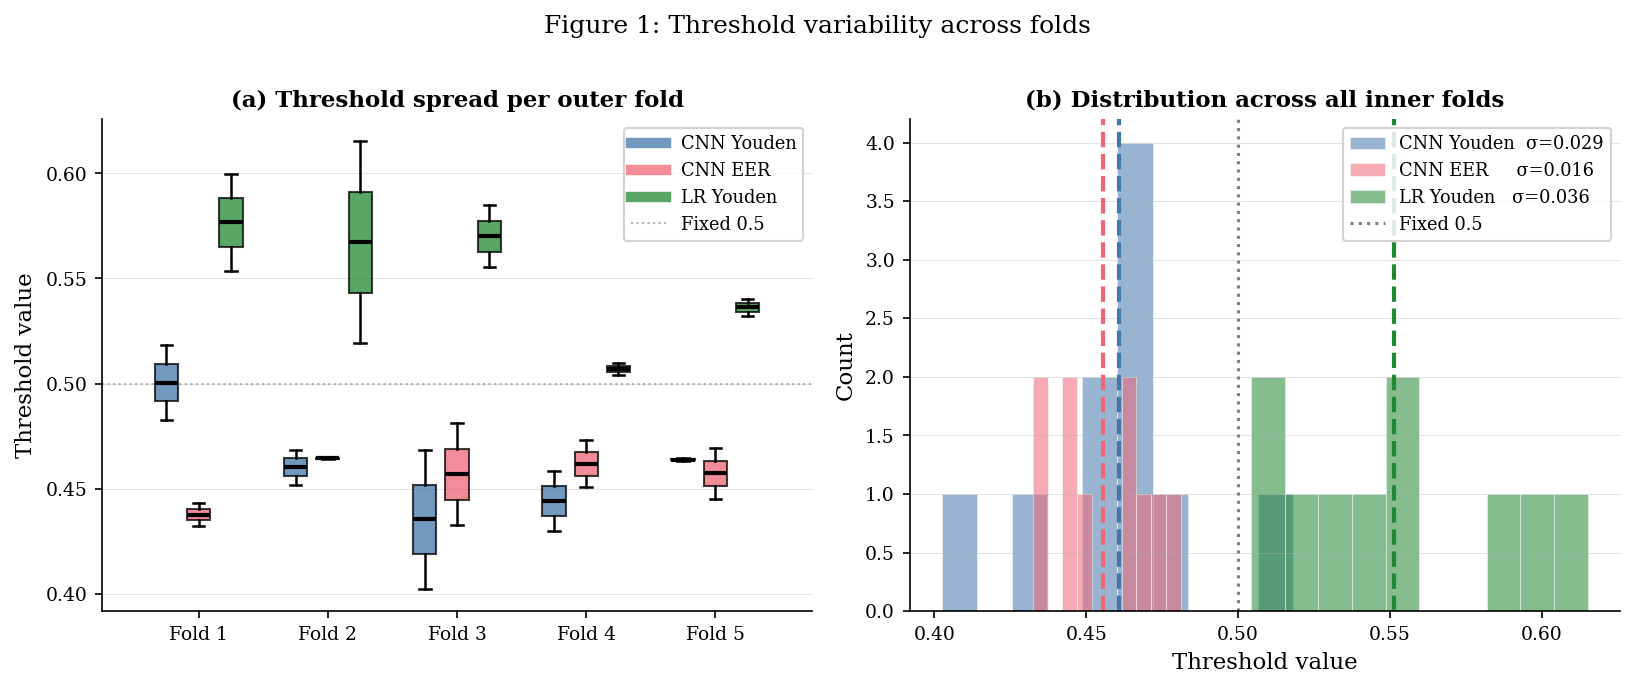


EXP 2 — AUC STABILITY vs THRESHOLD INSTABILITY
  AUC           μ=0.9622  σ=0.0052  range=0.0154
  Youden thresh μ=0.4625  σ=0.0176  range=0.0530
  EER thresh    μ=0.4547  σ=0.0167  range=0.0488
  Instability ratio (Youden σ / AUC σ): 3.41×


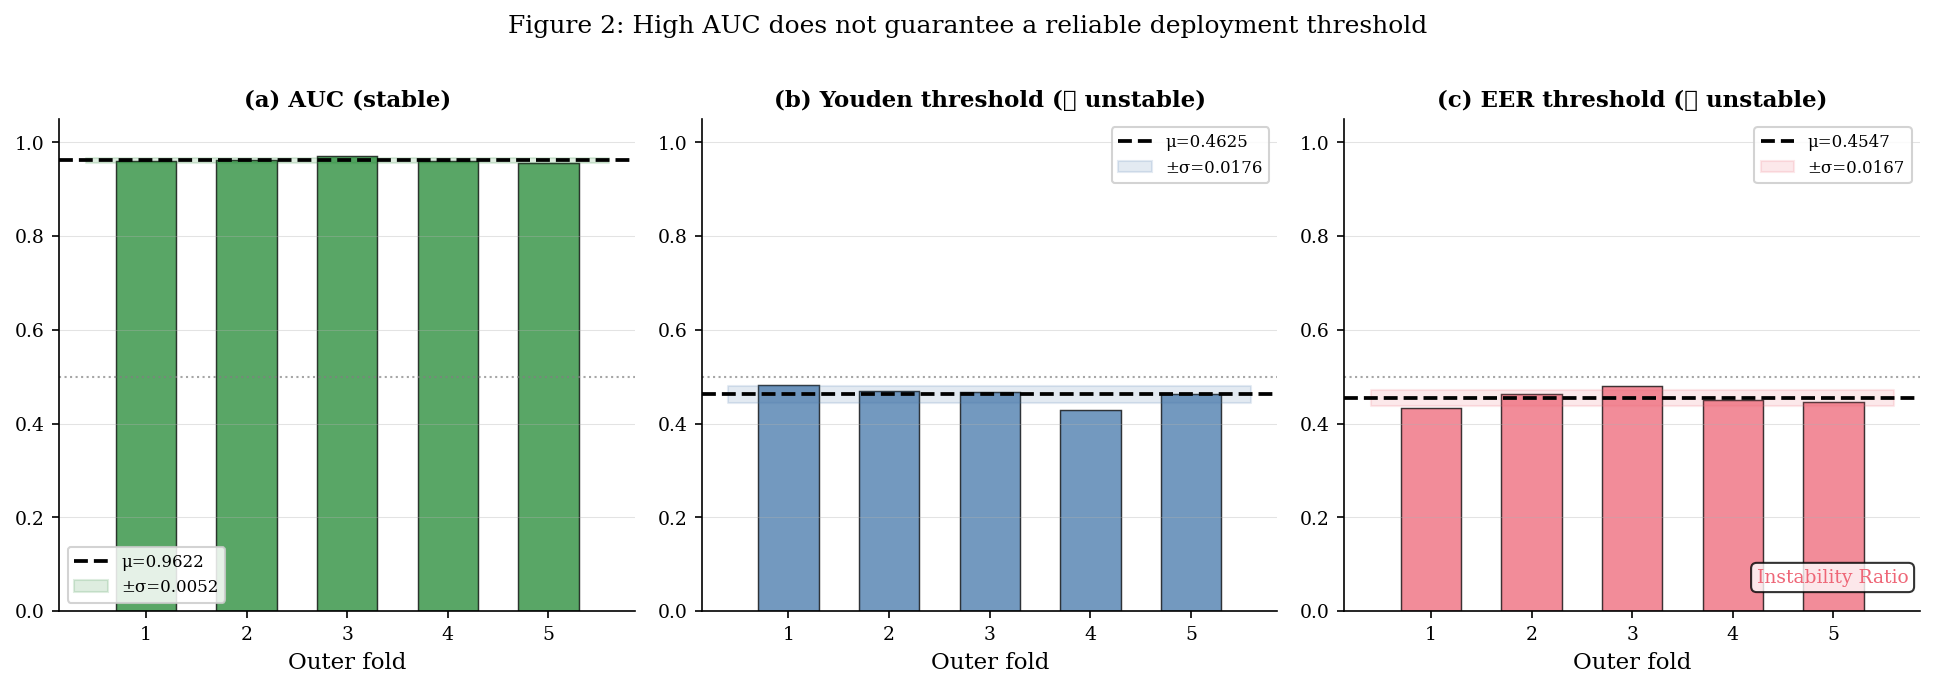


EXP 3 — THRESHOLD STRATEGY COMPARISON
                     accuracy               f1      sensitivity      specificity              far              frr        threshold
Strategy                                                                                                                           
Youden J      0.8909 ± 0.0092  0.9076 ± 0.0084  0.8880 ± 0.0177  0.8953 ± 0.0182  0.1047 ± 0.0182  0.1120 ± 0.0177  0.4625 ± 0.0176
EER           0.8925 ± 0.0078  0.9094 ± 0.0063  0.8931 ± 0.0059  0.8915 ± 0.0160  0.1085 ± 0.0160  0.1069 ± 0.0059  0.4547 ± 0.0167
Fixed 0.5     0.8870 ± 0.0084  0.9030 ± 0.0077  0.8708 ± 0.0129  0.9119 ± 0.0099  0.0881 ± 0.0099  0.1292 ± 0.0129  0.5000 ± 0.0000
Platt+Youden  0.8939 ± 0.0099  0.9103 ± 0.0089  0.8923 ± 0.0142  0.8964 ± 0.0043  0.1036 ± 0.0043  0.1077 ± 0.0142  0.5650 ± 0.0338
Temp+Youden   0.8939 ± 0.0099  0.9103 ± 0.0089  0.8923 ± 0.0142  0.8964 ± 0.0043  0.1036 ± 0.0043  0.1077 ± 0.0142  0.4476 ± 0.0295


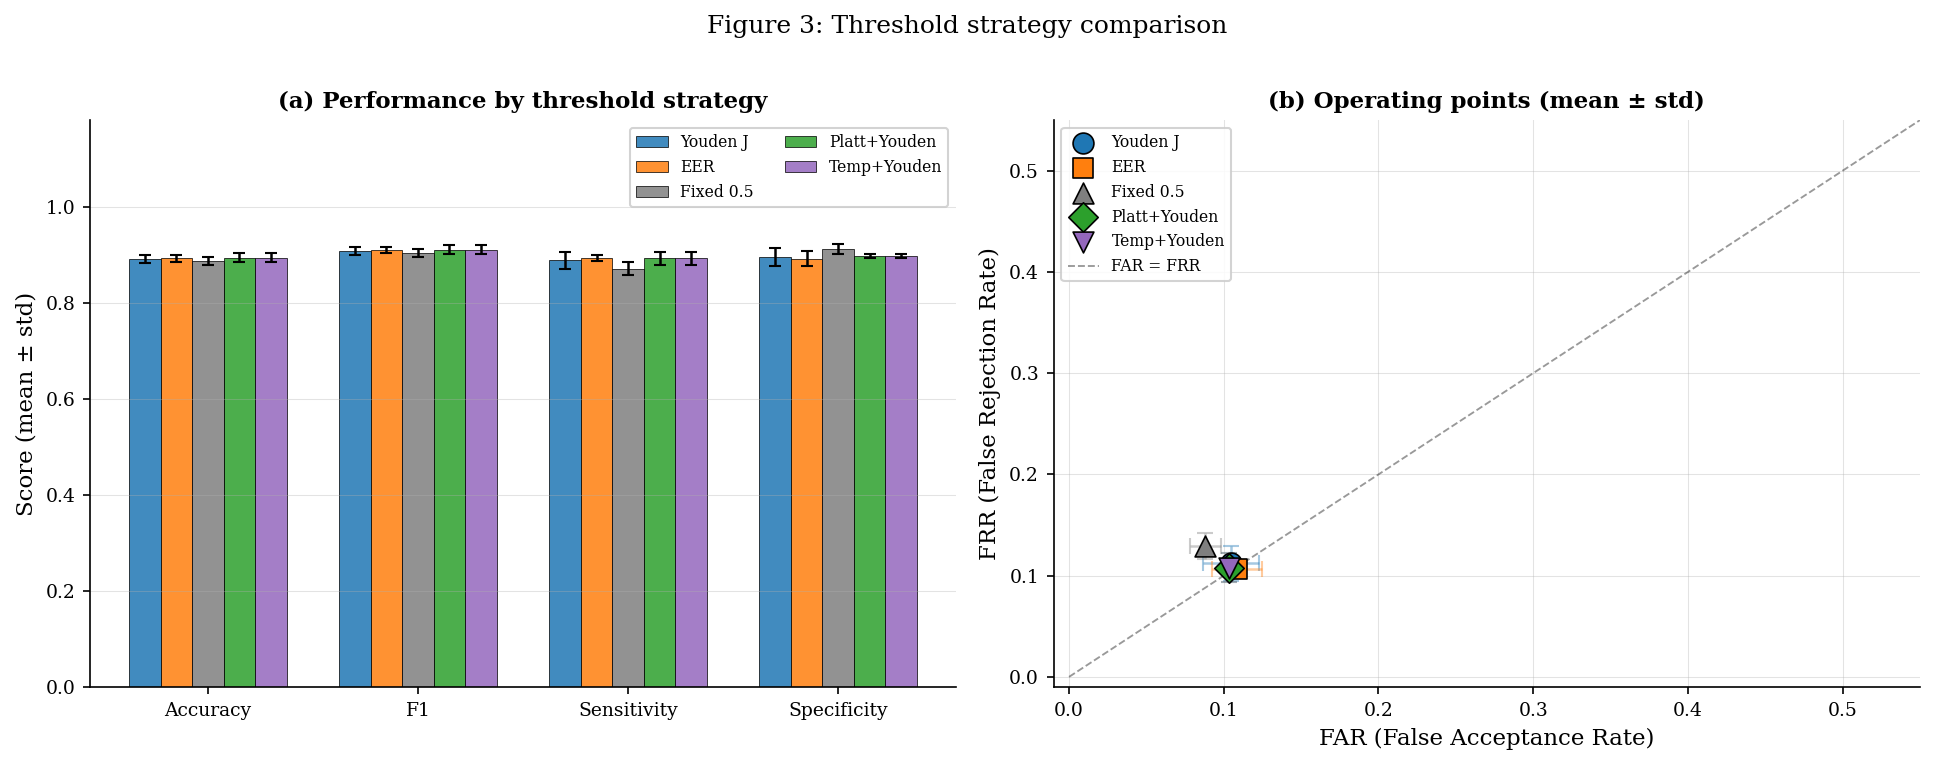


EXP 4 — PERTURBATION SENSITIVITY (best model fold 3)
  noise=0.00  AUC=0.9719  Youden=0.4363  EER=0.4574  F1=0.9271
  noise=0.01  AUC=0.9719  Youden=0.4350  EER=0.4579  F1=0.9271
  noise=0.05  AUC=0.9719  Youden=0.4253  EER=0.4552  F1=0.9277
  noise=0.10  AUC=0.9719  Youden=0.4254  EER=0.4519  F1=0.9272


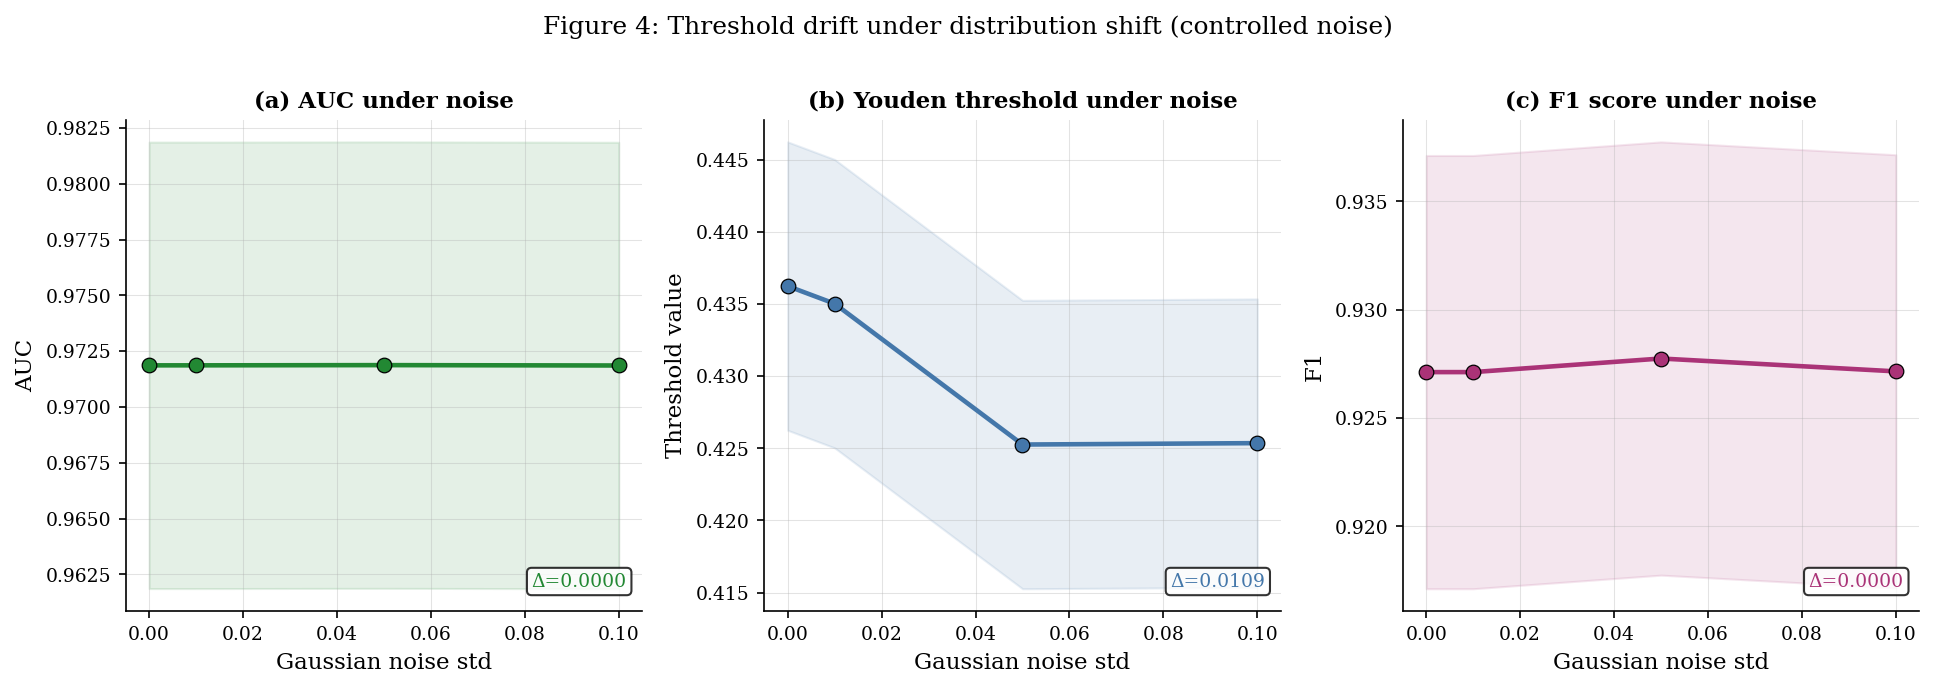


EXP 5 — CALIBRATION IMPACT
  Threshold σ  Raw=0.0176  Platt=0.0338  Temp=0.0295
  ECE Raw        μ=0.0471  σ=0.0045
  ECE Platt      μ=0.0142  σ=0.0028
  ECE Temp       μ=0.0377  σ=0.0054
  Brier Raw      μ=0.0798  σ=0.0052
  Brier Platt    μ=0.0754  σ=0.0054
  Brier Temp     μ=0.0791  σ=0.0055


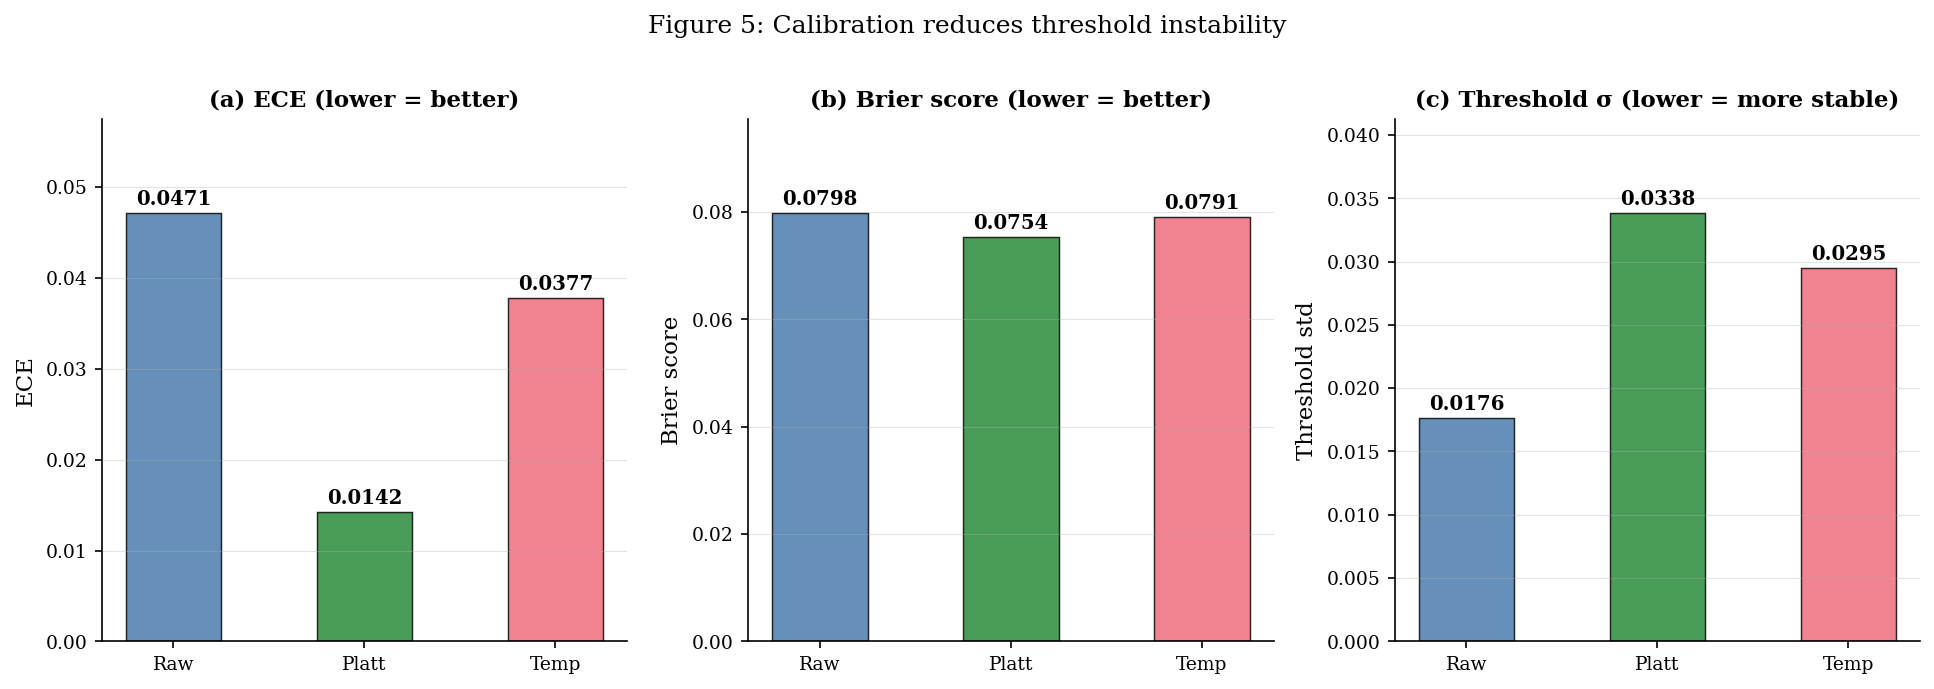

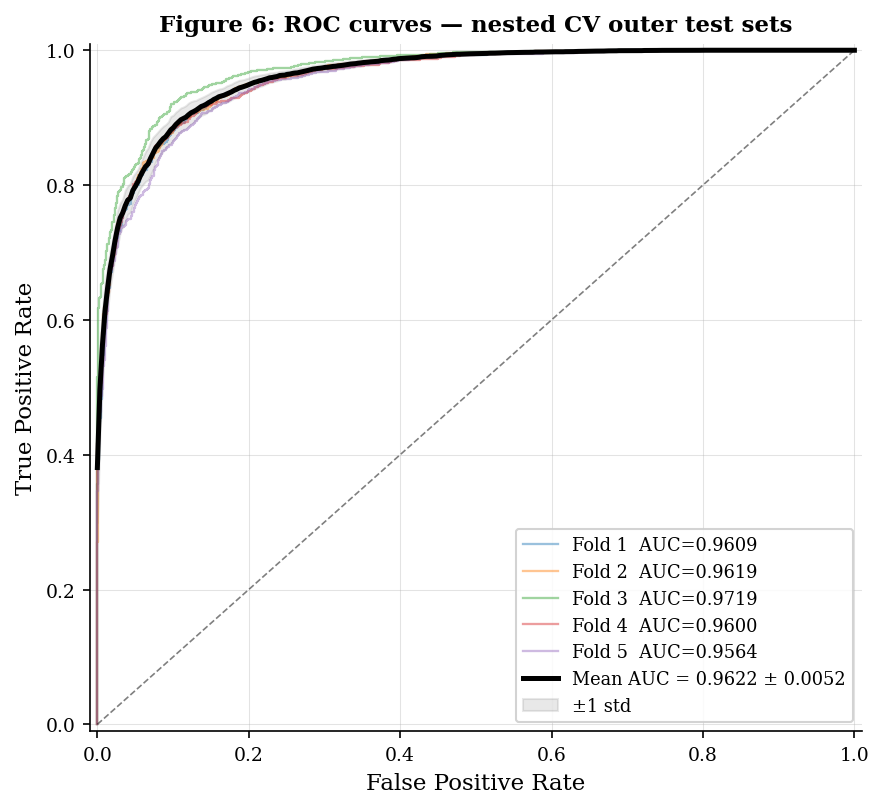

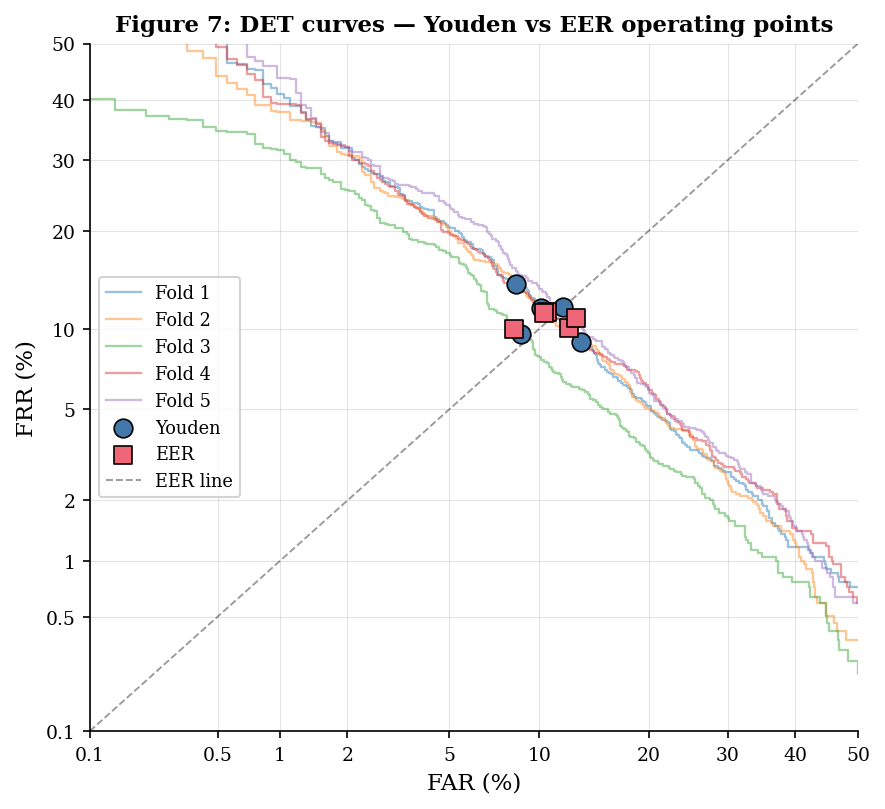


All 7 figures saved as PDF.


In [9]:
# ── Shared data extraction ────────────────────────────────────────
all_cnn_youden = [t for r in fold_records for t in r['inner_youden_thresholds']]
all_cnn_eer    = [t for r in fold_records for t in r['inner_eer_thresholds']]
all_lr_youden  = [t for r in fold_records for t in r['lr_youden_thresholds']]
all_j_scores   = [t for r in fold_records for t in r['inner_j_scores']]
auc_per_fold   = [r['youden']['auc']  for r in fold_records]
yt_per_fold    = [r['youden_thresh']  for r in fold_records]
et_per_fold    = [r['eer_thresh']     for r in fold_records]
auc_std = np.std(auc_per_fold)
y_std   = np.std(yt_per_fold)
e_std   = np.std(et_per_fold)
ratio   = y_std / (auc_std + 1e-8)
folds   = np.arange(1, OUTER_SPLITS+1)
STRATEGIES = ['youden','eer','fixed','platt','temp']
S_LABELS   = {'youden':'Youden J','eer':'EER','fixed':'Fixed 0.5',
               'platt':'Platt+Youden','temp':'Temp+Youden'}
S_COLORS   = {'youden':PAL[0],'eer':PAL[1],'fixed':PAL[7],
               'platt':PAL[2],'temp':PAL[4]}
S_MARKERS  = {'youden':'o','eer':'s','fixed':'^','platt':'D','temp':'v'}

# ─────────────────────────────────────────────────────────────────
# EXP 1  Threshold Variability (Figure 1)
# ─────────────────────────────────────────────────────────────────
print("EXP 1 — THRESHOLD VARIABILITY")
SIG = 0.05
for name, vals in [
    ('CNN Youden (inner)', all_cnn_youden),
    ('CNN EER    (inner)', all_cnn_eer),
    ('LR  Youden (inner)', all_lr_youden),
]:
    v = np.array(vals)
    flag = '✅' if v.std() > SIG else '—'
    print(f'  {name:<24} μ={v.mean():.4f}  σ={v.std():.4f}  '
          f'range={v.max()-v.min():.4f}  {flag}')
print(f'  LR σ={np.std(all_lr_youden):.4f}  CNN σ={np.std(all_cnn_youden):.4f}  '
      f'→ instability is framework-level, not CNN-specific')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: boxplot per outer fold
ax = axes[0]
youden_by = [r['inner_youden_thresholds'] for r in fold_records]
eer_by    = [r['inner_eer_thresholds']    for r in fold_records]
lr_by     = [r['lr_youden_thresholds']    for r in fold_records]
offsets   = [-0.25, 0, 0.25]
colors    = ['#4477AA', '#EE6677', '#228833']
labels_bp = ['CNN Youden', 'CNN EER', 'LR Youden']
for data, off, col, lbl in zip([youden_by, eer_by, lr_by], offsets, colors, labels_bp):
    bp = ax.boxplot(data, positions=folds+off, widths=0.18, patch_artist=True,
                    boxprops=dict(facecolor=col, alpha=0.75),
                    medianprops=dict(color='black', lw=2),
                    whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
                    flierprops=dict(marker='x', markersize=4, alpha=0.5))
    ax.plot([], [], color=col, lw=5, alpha=0.75, label=lbl)
ax.axhline(0.5, color='grey', lw=1, ls=':', alpha=0.6, label='Fixed 0.5')
ax.set_xticks(folds); ax.set_xticklabels([f'Fold {i}' for i in folds])
ax.set_ylabel('Threshold value')
ax.set_title('(a) Threshold spread per outer fold')
ax.legend(loc='upper right'); ax.grid(axis='y')

# Right: histogram
ax = axes[1]
for vals, col, lbl in [
    (all_cnn_youden, '#4477AA', f'CNN Youden  σ={np.std(all_cnn_youden):.3f}'),
    (all_cnn_eer,    '#EE6677', f'CNN EER     σ={np.std(all_cnn_eer):.3f}'),
    (all_lr_youden,  '#228833', f'LR Youden   σ={np.std(all_lr_youden):.3f}'),
]:
    ax.hist(vals, bins=10, alpha=0.55, color=col, label=lbl, edgecolor='white', lw=0.4)
    ax.axvline(np.mean(vals), color=col, lw=2, ls='--')
ax.axvline(0.5, color='grey', lw=1.5, ls=':', label='Fixed 0.5')
ax.set_xlabel('Threshold value'); ax.set_ylabel('Count')
ax.set_title('(b) Distribution across all inner folds')
ax.legend(); ax.grid(axis='y')

fig.suptitle('Figure 1: Threshold variability across folds', y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/fig1_threshold_variability.pdf')
plt.show()
print()

# ─────────────────────────────────────────────────────────────────
# EXP 2  AUC Stability vs Threshold Instability (Figure 2)
# ─────────────────────────────────────────────────────────────────
print("EXP 2 — AUC STABILITY vs THRESHOLD INSTABILITY")
print(f'  AUC           μ={np.mean(auc_per_fold):.4f}  σ={auc_std:.4f}  '
      f'range={max(auc_per_fold)-min(auc_per_fold):.4f}')
print(f'  Youden thresh μ={np.mean(yt_per_fold):.4f}  σ={y_std:.4f}  '
      f'range={max(yt_per_fold)-min(yt_per_fold):.4f}')
print(f'  EER thresh    μ={np.mean(et_per_fold):.4f}  σ={e_std:.4f}  '
      f'range={max(et_per_fold)-min(et_per_fold):.4f}')
print(f'  Instability ratio (Youden σ / AUC σ): {ratio:.2f}×')

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, vals, col, lbl, title in [
    (axes[0], auc_per_fold, '#228833', f'μ={np.mean(auc_per_fold):.4f}', 'AUC (stable)'),
    (axes[1], yt_per_fold,  '#4477AA', f'μ={np.mean(yt_per_fold):.4f}',  'Youden threshold (⚠ unstable)'),
    (axes[2], et_per_fold,  '#EE6677', f'μ={np.mean(et_per_fold):.4f}',  'EER threshold (⚠ unstable)'),
]:
    ax.bar(folds, vals, color=col, alpha=0.75, edgecolor='black', lw=0.7, width=0.6)
    ax.axhline(np.mean(vals), color='black', lw=1.8, ls='--', label=lbl)
    std = np.std(vals)
    ax.fill_between([0.4, OUTER_SPLITS+0.6], np.mean(vals)-std, np.mean(vals)+std,
                    color=col, alpha=0.15, label=f'±σ={std:.4f}')
    ax.axhline(0.5, color='grey', lw=1, ls=':', alpha=0.7)
    ax.set_ylim(0, 1.05); ax.set_xticks(folds)
    ax.set_xlabel('Outer fold'); ax.set_ylabel(ax.get_ylabel())
    ax.set_title(f'({"abc"[axes.tolist().index(ax)]}) {title}')
    ax.legend(fontsize=8); ax.grid(axis='y')

# Annotate instability ratio on right panel
axes[2].text(0.98, 0.05, "Instability Ratio", # Added the missing string
             transform=axes[2].transAxes, ha='right', va='bottom',
             fontsize=9, color='#EE6677',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

fig.suptitle('Figure 2: High AUC does not guarantee a reliable deployment threshold', y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/fig2_auc_vs_threshold.pdf')
plt.show()
print()

# ─────────────────────────────────────────────────────────────────
# EXP 3  Strategy Comparison (Figure 3)
# ─────────────────────────────────────────────────────────────────
print("EXP 3 — THRESHOLD STRATEGY COMPARISON")
m_keys = ['accuracy','f1','sensitivity','specificity','far','frr','threshold']
rows = []
for s in STRATEGIES:
    row = {'Strategy': S_LABELS[s]}
    for k in m_keys:
        v = np.array([r[s][k] for r in fold_records])
        row[k] = f'{v.mean():.4f} ± {v.std():.4f}'
    rows.append(row)
print(pd.DataFrame(rows).set_index('Strategy').to_string())

plot_m = ['accuracy','f1','sensitivity','specificity']
x = np.arange(len(plot_m)); width = 0.15
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for i, s in enumerate(STRATEGIES):
    means = [np.mean([r[s][m] for r in fold_records]) for m in plot_m]
    stds  = [np.std( [r[s][m] for r in fold_records]) for m in plot_m]
    off   = (i - len(STRATEGIES)/2 + 0.5) * width
    ax.bar(x+off, means, width=width, yerr=stds, label=S_LABELS[s],
           color=S_COLORS[s], alpha=0.85, capsize=3,
           error_kw={'elinewidth':1.2}, edgecolor='black', lw=0.4)
ax.set_xticks(x); ax.set_xticklabels([m.capitalize() for m in plot_m])
ax.set_ylim(0, 1.18); ax.set_ylabel('Score (mean ± std)')
ax.set_title('(a) Performance by threshold strategy')
ax.legend(fontsize=7.5, ncol=2); ax.grid(axis='y')

ax = axes[1]
for s in STRATEGIES:
    far_v = [r[s]['far'] for r in fold_records]
    frr_v = [r[s]['frr'] for r in fold_records]
    ax.scatter(np.mean(far_v), np.mean(frr_v), s=100,
               color=S_COLORS[s], marker=S_MARKERS[s], zorder=5,
               edgecolors='black', lw=0.8, label=S_LABELS[s])
    ax.errorbar(np.mean(far_v), np.mean(frr_v),
                xerr=np.std(far_v), yerr=np.std(frr_v),
                color=S_COLORS[s], alpha=0.4, capsize=4, lw=1.2)
ax.plot([0,0.6],[0,0.6],'k--', lw=0.9, alpha=0.4, label='FAR = FRR')
ax.set_xlabel('FAR (False Acceptance Rate)')
ax.set_ylabel('FRR (False Rejection Rate)')
ax.set_title('(b) Operating points (mean ± std)')
ax.legend(fontsize=7.5); ax.grid()
ax.set_xlim(-0.01, 0.55); ax.set_ylim(-0.01, 0.55)

fig.suptitle('Figure 3: Threshold strategy comparison', y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/fig3_strategy_comparison.pdf')
plt.show()
print()

# ─────────────────────────────────────────────────────────────────
# EXP 4  Perturbation Sensitivity (Figure 4)
# ─────────────────────────────────────────────────────────────────
print(f"EXP 4 — PERTURBATION SENSITIVITY (best model fold {best_outer_fold})")
model_best = DeepfakeDetector().to(device)
model_best.load_state_dict(best_model_state); model_best.eval()
rng = np.random.default_rng(RANDOM_STATE)
perturb_results = []

for ns in NOISE_LEVELS:
    X_noisy = X.copy()
    if ns > 0:
        X_noisy[best_outer_test_idx] = (
            X[best_outer_test_idx]
            + rng.normal(0, ns, X[best_outer_test_idx].shape)
        ).astype(np.float32)
    _, nprobs, nlabels = get_logits_probs(
        model_best, make_loader(AudioDataset(X_noisy, y), best_outer_test_idx))
    yt, jv, _, _     = youden_threshold(nprobs, nlabels)
    et, ev, _, _, _  = eer_threshold(nprobs, nlabels)
    m                = full_metrics(nprobs, nlabels, yt)
    perturb_results.append(dict(noise_std=ns, auc=m['auc'], youden_thresh=yt,
                                eer_thresh=et, f1=m['f1'], far=m['far'], frr=m['frr']))
    print(f'  noise={ns:.2f}  AUC={m["auc"]:.4f}  '
          f'Youden={yt:.4f}  EER={et:.4f}  F1={m["f1"]:.4f}')

noises = [r['noise_std'] for r in perturb_results]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
plot_spec = [
    ('auc',           '#228833', 'AUC',            'AUC'),
    ('youden_thresh', '#4477AA', 'Youden threshold','Threshold value'),
    ('f1',            '#AA3377', 'F1 score',        'F1'),
]
for ax, (key, col, lbl, ylabel), letter in zip(axes, plot_spec, 'abc'):
    vals = [r[key] for r in perturb_results]
    ax.plot(noises, vals, color=col, lw=2.2, marker='o', ms=7,
            markeredgecolor='black', markeredgewidth=0.6)
    ax.fill_between(noises, np.array(vals)-0.01, np.array(vals)+0.01,
                    color=col, alpha=0.12)
    ax.set_xlabel('Gaussian noise std')
    ax.set_ylabel(ylabel)
    ax.set_title(f'({letter}) {lbl} under noise')
    ax.grid()
    # annotate shift
    shift = abs(vals[-1]-vals[0])
    ax.text(0.97, 0.05, f'Δ={shift:.4f}',
            transform=ax.transAxes, ha='right', fontsize=9,
            color=col, bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.8))

fig.suptitle('Figure 4: Threshold drift under distribution shift (controlled noise)', y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/fig4_perturbation.pdf')
plt.show()
print()

# ─────────────────────────────────────────────────────────────────
# EXP 5  Calibration Impact (Figure 5)
# ─────────────────────────────────────────────────────────────────
print("EXP 5 — CALIBRATION IMPACT")
df_c = pd.DataFrame([{
    'Fold':r['outer_fold'],
    'ECE Raw':r['ece_raw'], 'ECE Platt':r['ece_platt'], 'ECE Temp':r['ece_temp'],
    'Brier Raw':r['youden']['brier'], 'Brier Platt':r['platt']['brier'], 'Brier Temp':r['temp']['brier'],
    'Thresh Raw':r['youden_thresh'], 'Thresh Platt':r['platt']['threshold'], 'Thresh Temp':r['temp']['threshold'],
    'F1 Raw':r['youden']['f1'], 'F1 Platt':r['platt']['f1'], 'F1 Temp':r['temp']['f1'],
} for r in fold_records]).set_index('Fold')

ts_raw, ts_platt, ts_temp = (np.std(df_c[k].values)
    for k in ['Thresh Raw','Thresh Platt','Thresh Temp'])
print(f'  Threshold σ  Raw={ts_raw:.4f}  Platt={ts_platt:.4f}  Temp={ts_temp:.4f}')
for col in ['ECE Raw','ECE Platt','ECE Temp','Brier Raw','Brier Platt','Brier Temp']:
    v = df_c[col].values
    print(f'  {col:<14} μ={v.mean():.4f}  σ={v.std():.4f}')

methods   = ['Raw','Platt','Temp']
mcols     = ['#4477AA','#228833','#EE6677']
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (title, vals, ylabel, letter) in zip(axes, [
    ('ECE (lower = better)',
     [df_c['ECE Raw'].mean(), df_c['ECE Platt'].mean(), df_c['ECE Temp'].mean()],
     'ECE', 'a'),
    ('Brier score (lower = better)',
     [df_c['Brier Raw'].mean(), df_c['Brier Platt'].mean(), df_c['Brier Temp'].mean()],
     'Brier score', 'b'),
    ('Threshold σ (lower = more stable)',
     [ts_raw, ts_platt, ts_temp],
     'Threshold std', 'c'),
]):
    bars = ax.bar(methods, vals, color=mcols, alpha=0.82,
                  edgecolor='black', lw=0.7, width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9.5, fontweight='bold')
    ax.set_title(f'({letter}) {title}')
    ax.set_ylabel(ylabel); ax.grid(axis='y')
    ax.set_ylim(0, max(vals)*1.22)

fig.suptitle('Figure 5: Calibration reduces threshold instability', y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/fig5_calibration.pdf')
plt.show()
print()

# ─────────────────────────────────────────────────────────────────
# Figure 6  ROC Curves
# ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5.5))
mean_fpr    = np.linspace(0, 1, 300)
tprs_interp = []
for i, (fpr, tpr, fold_auc) in enumerate(roc_curves):
    ax.plot(fpr, tpr, lw=1.1, alpha=0.45, color=PAL[i], label=f'Fold {i+1}  AUC={fold_auc:.4f}')
    fi = interp1d(fpr, tpr, kind='linear', bounds_error=False, fill_value=(0,1))
    tprs_interp.append(fi(mean_fpr))
mean_tpr = np.mean(tprs_interp, axis=0)
std_tpr  = np.std(tprs_interp,  axis=0)
mean_auc_v = np.mean([d[2] for d in roc_curves])
std_auc_v  = np.std( [d[2] for d in roc_curves])
ax.plot(mean_fpr, mean_tpr, color='black', lw=2.4,
        label=f'Mean AUC = {mean_auc_v:.4f} ± {std_auc_v:.4f}')
ax.fill_between(mean_fpr, mean_tpr-std_tpr, mean_tpr+std_tpr,
                color='grey', alpha=0.18, label='±1 std')
ax.plot([0,1],[0,1],'k--', lw=0.8, alpha=0.5)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('Figure 6: ROC curves — nested CV outer test sets')
ax.legend(loc='lower right'); ax.grid()
ax.set_xlim(-0.01,1.01); ax.set_ylim(-0.01,1.01)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/fig6_roc.pdf')
plt.show()

# ─────────────────────────────────────────────────────────────────
# Figure 7  DET Curves
# ─────────────────────────────────────────────────────────────────
def nd(rate): return norm.ppf(np.clip(rate, 1e-6, 1-1e-6))

fig, ax = plt.subplots(figsize=(6, 5.5))
for i, (fpr, fnr) in enumerate(det_curves):
    ax.plot(nd(fpr), nd(fnr), lw=1.1, alpha=0.45, color=PAL[i], label=f'Fold {i+1}')
for s, col, mk, lbl in [
    ('youden','#4477AA','o','Youden'), ('eer','#EE6677','s','EER')
]:
    ax.scatter(nd([r[s]['far'] for r in fold_records]),
               nd([r[s]['frr'] for r in fold_records]),
               s=80, color=col, marker=mk, zorder=6, edgecolors='black', lw=0.8, label=lbl)
ticks   = [0.001,0.005,0.01,0.02,0.05,0.10,0.20,0.30,0.40,0.50]
tlabels = ['0.1','0.5','1','2','5','10','20','30','40','50']
nd_t = [nd(t) for t in ticks]
ax.plot(nd_t, nd_t, 'k--', lw=0.9, alpha=0.4, label='EER line')
ax.set_xticks(nd_t); ax.set_xticklabels(tlabels)
ax.set_yticks(nd_t); ax.set_yticklabels(tlabels)
ax.set_xlabel('FAR (%)'); ax.set_ylabel('FRR (%)')
ax.set_title('Figure 7: DET curves — Youden vs EER operating points')
ax.legend(); ax.grid()
ax.set_xlim(nd_t[0], nd_t[-1]); ax.set_ylim(nd_t[0], nd_t[-1])
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/fig7_det.pdf')
plt.show()
print()
print("All 7 figures saved as PDF.")


## Cell 8 — Statistical Tests & Final Results Table

In [10]:
# ── Wilcoxon signed-rank tests (non-parametric, appropriate for N=5 folds) ──
print("STATISTICAL TESTS")
print("="*60)
youden_f1   = [r['youden']['f1'] for r in fold_records]
eer_f1      = [r['eer']['f1']    for r in fold_records]
raw_thresh  = [r['youden_thresh']           for r in fold_records]
platt_thresh= [r['platt']['threshold']      for r in fold_records]
temp_thresh = [r['temp']['threshold']       for r in fold_records]

for name, a, b in [
    ('Youden F1 vs EER F1',        youden_f1,   eer_f1),
    ('Raw thresh vs Platt thresh', raw_thresh,  platt_thresh),
    ('Raw thresh vs Temp  thresh', raw_thresh,  temp_thresh),
]:
    diffs = [x-y for x,y in zip(a,b)]
    if len(set(diffs)) > 1:
        stat, p = wilcoxon(a, b, alternative='two-sided')
        sig = "significant (p<0.05)" if p < 0.05 else "not significant"
        print(f'  {name}: W={stat:.1f}  p={p:.4f}  {sig}')
    else:
        print(f'  {name}: identical — test not applicable')

# ── Bootstrap CI on instability ratio ────────────────────────────
rng_boot = np.random.default_rng(RANDOM_STATE)
auc_arr  = np.array([r['youden']['auc']  for r in fold_records])
thr_arr  = np.array([r['youden_thresh']  for r in fold_records])
boot_r   = []
for _ in range(10_000):
    idx = rng_boot.integers(0, len(fold_records), len(fold_records))
    a_s, t_s = np.std(auc_arr[idx]), np.std(thr_arr[idx])
    if a_s > 1e-8:
        boot_r.append(t_s / a_s)
point = np.mean(boot_r)
ci_lo = np.percentile(boot_r, 2.5)
ci_hi = np.percentile(boot_r, 97.5)
print(f'\n  Instability ratio: {point:.2f}× [95% CI {ci_lo:.2f}×–{ci_hi:.2f}×]')
print(f'  Thresholds vary {point:.1f}× more than AUC across folds')

# ── Final aggregated results table ───────────────────────────────
print('\nFINAL RESULTS TABLE (mean ± std  [2.5%, 97.5% CI])')
print('='*80)
def agg(vals):
    v = np.array(vals)
    return f'{v.mean():.4f} ± {v.std():.4f}  [{np.percentile(v,2.5):.4f}, {np.percentile(v,97.5):.4f}]'

for skey, sname in [('youden','Youden J'),('eer','EER'),
                     ('fixed','Fixed 0.5'),('platt','Platt+Youden'),('temp','Temp+Youden')]:
    print(f'\n  ── {sname} ──')
    for metric in ['auc','accuracy','f1','sensitivity','specificity','far','frr','brier','threshold']:
        print(f'    {metric:<14} {agg([r[skey][metric] for r in fold_records])}')

print('\n  ── Stability metrics ──')
print(f'    {"AUC σ":<20} {agg(auc_arr.tolist())}')
print(f'    {"Youden thresh σ":<20} {agg(thr_arr.tolist())}')
print(f'    {"EER thresh σ":<20} {agg([r["eer_thresh"] for r in fold_records])}')
print(f'    {"ECE (raw)":<20} {agg([r["ece_raw"]   for r in fold_records])}')
print(f'    {"ECE (Platt)":<20} {agg([r["ece_platt"] for r in fold_records])}')
print(f'    {"Instability ratio":<20} {point:.2f}×  [95% CI {ci_lo:.2f}×, {ci_hi:.2f}×]')

# ── Save model ───────────────────────────────────────────────────
SAVE_PATH = 'deepfake_threshold_stability.pth'
torch.save({
    'model_state_dict' : best_model_state,
    'best_outer_fold'  : best_outer_fold,
    'best_auc'         : best_global_auc,
    'youden_threshold' : fold_records[best_outer_fold-1]['youden_thresh'],
    'outer_splits'     : OUTER_SPLITS,
    'inner_splits'     : INNER_SPLITS,
    'dataset'          : 'IndieFake',
    'feature_params'   : dict(type='Log-Mel spectrogram', sample_rate=16000,
                               n_mels=128, n_frames=94, window_ms=25, hop_ms=10),
    'fold_results'     : [{k:v for k,v in r.items()
                           if k not in ('youden','eer','fixed','platt','temp','test_idx')}
                          for r in fold_records],
    'perturb_results'  : perturb_results,
    'instability_ratio': dict(point=point, ci_lo=ci_lo, ci_hi=ci_hi),
}, SAVE_PATH)
print(f'\n✅ Model saved → {SAVE_PATH}')
print('✅ 7 publication-quality PDF figures saved.')
print('To load for inference:')
print("  ckpt = torch.load('deepfake_threshold_stability.pth')")
print("  model.load_state_dict(ckpt['model_state_dict'])")
print("  threshold = ckpt['youden_threshold']")


STATISTICAL TESTS
  Youden F1 vs EER F1: W=5.0  p=0.6250  not significant
  Raw thresh vs Platt thresh: W=0.0  p=0.0625  not significant
  Raw thresh vs Temp  thresh: W=5.0  p=0.6250  not significant

  Instability ratio: 6.17× [95% CI 0.33×–32.97×]
  Thresholds vary 6.2× more than AUC across folds

FINAL RESULTS TABLE (mean ± std  [2.5%, 97.5% CI])

  ── Youden J ──
    auc            0.9622 ± 0.0052  [0.9568, 0.9709]
    accuracy       0.8909 ± 0.0092  [0.8821, 0.9058]
    f1             0.9076 ± 0.0084  [0.8985, 0.9207]
    sensitivity    0.8880 ± 0.0177  [0.8627, 0.9097]
    specificity    0.8953 ± 0.0182  [0.8691, 0.9153]
    far            0.1047 ± 0.0182  [0.0847, 0.1309]
    frr            0.1120 ± 0.0177  [0.0903, 0.1373]
    brier          0.0798 ± 0.0052  [0.0709, 0.0847]
    threshold      0.4625 ± 0.0176  [0.4330, 0.4812]

  ── EER ──
    auc            0.9622 ± 0.0052  [0.9568, 0.9709]
    accuracy       0.8925 ± 0.0078  [0.8841, 0.9054]
    f1             0.9094 ± 0.0063